# Student Performance Analysis

#1 Loading the Dataset
We will start by loading the 'student-mat' dataset with the help of Pandas library by importing it as pd.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style immediately to upgrade your visual appeal
sns.set_theme(style="whitegrid")

# Load the dataset correctly using the semicolon separator
df = pd.read_csv('D:\maincraft\student\student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
# Check missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Inspect dataset shape & dtypes
print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Data Types ---")
print(df.dtypes)

--- Missing Values ---
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

--- Dataset Shape ---
Rows: 395, Columns: 33

--- Data Types ---
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid         

#2 Explore and clean the dataset
We will check for the null values in the dataset. And remove the duplicates (if any) and inspect the shape and the data types of the dataset.

In [3]:
# Check unique values for a quick data integrity audit
print(df['Mjob'].unique())

['at_home' 'health' 'other' 'services' 'teacher']


#4 Additionally, we will inspect the shape and data types

In [4]:
# 1. Average final grade (G3)
avg_g3 = df['G3'].mean()
print(f"Average Final Grade (G3): {avg_g3:.2f}")

# 2. How many students scored above 15?
students_above_15 = df[df['G3'] > 15].shape[0]
print(f"Students scoring above 15: {students_above_15}")

# 3. Is study time correlated with performance?
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and G3: {correlation:.4f}")

# 4. Which gender performs better on average?
gender_perf = df.groupby('sex')['G3'].mean()
print("\nAverage G3 by Gender:")
print(gender_perf)

Average Final Grade (G3): 10.42
Students scoring above 15: 40
Correlation between study time and G3: 0.0978

Average G3 by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


In [5]:
# Track if a student improved or dropped between midterms
df['grade_trajectory'] = df['G2'] - df['G1']
print("\nAverage grade trajectory calculated successfully.")


Average grade trajectory calculated successfully.


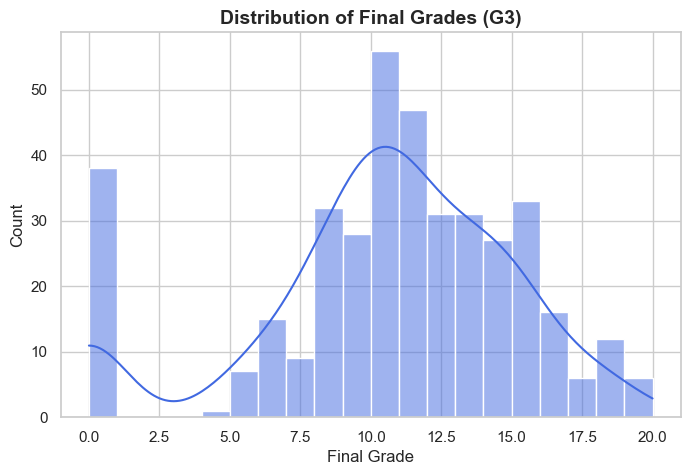

In [6]:
# 1. Histogram of grades
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='royalblue')
plt.title('Distribution of Final Grades (G3)', fontsize=14, fontweight='bold')
plt.xlabel('Final Grade')
plt.ylabel('Count')
plt.show()



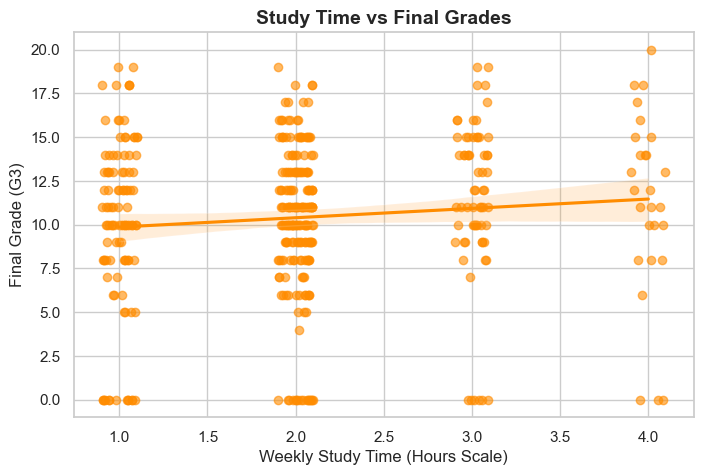

In [7]:
# 2. Scatterplot: study time vs grades (with a trend line!)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='studytime', y='G3', x_jitter=0.1, color='darkorange', scatter_kws={'alpha':0.6})
plt.title('Study Time vs Final Grades', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Study Time (Hours Scale)')
plt.ylabel('Final Grade (G3)')
plt.show()

C:\Users\Shruti Nair\AppData\Local\Temp\ipykernel_34708\3355257341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='G3', palette='Set2', errorbar=None)


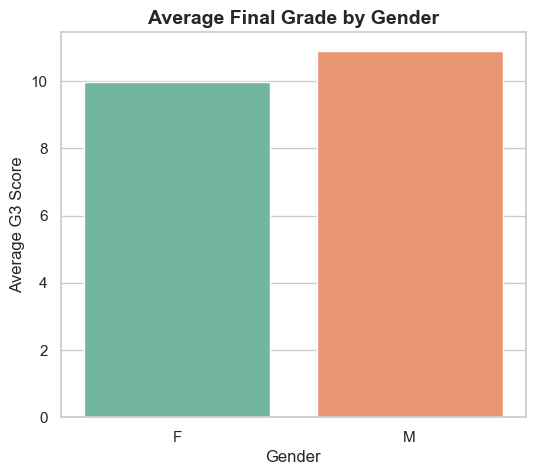

In [8]:
# 3. Bar chart: male vs female average score
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='sex', y='G3', palette='Set2', errorbar=None)
plt.title('Average Final Grade by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average G3 Score')
plt.show()

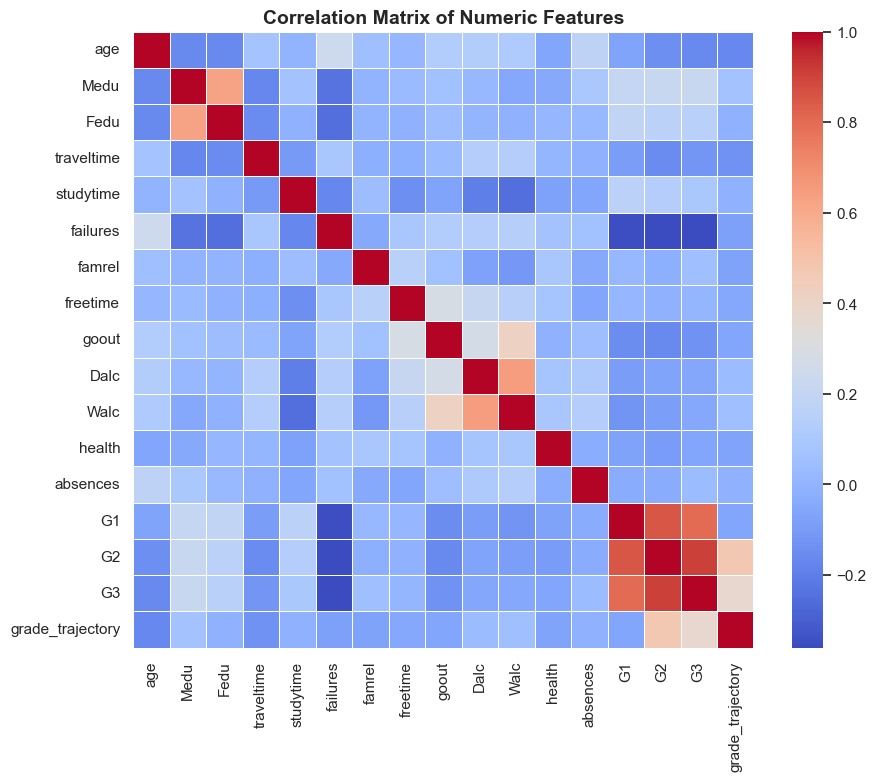

In [9]:
plt.figure(figsize=(10, 8))
# Drop non-numeric for correlation check
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.show()